<a href="https://colab.research.google.com/github/Daimond92/TelecomX-data-science/blob/develop/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importaciones

In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from os import truncate

#📌 Extracción de Datos

In [166]:
# Leer el archivo JSON directamente desde la URL
url = "https://raw.githubusercontent.com/Daimond92/TelecomX-data-science/refs/heads/develop/Data/TelecomX_Data.json"
df = pd.read_json(url)

# Mostrar las primeras filas del DataFrame
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
# URL del archivo Markdown
url = 'https://raw.githubusercontent.com/Daimond92/TelecomX-data-science/refs/heads/develop/Data/TelecomX_diccionario.md'

# Descargar el archivo Markdown
response = requests.get(url)

# Obtener el contenido como texto
md_text = response.text

In [28]:
# Extraer las líneas que contienen el diccionario de datos
pattern = r"- `([^`]+)`:\s*(.+)"
matches = re.findall(pattern, md_text)

# Crear un DataFrame con las columnas 'Variable' y 'Descripción'
df_diccionario = pd.DataFrame(matches, columns=['Variable', 'Descripción'])

# Mostrar el diccionario de datos como un DataFrame
pd.set_option('display.max_colwidth', None)
df_diccionario

,Variable,Descripción
0,customerID,número de identificación único de cada cliente
1,Churn,si el cliente dejó o no la empresa
2,gender,género (masculino y femenino)
3,SeniorCitizen,información sobre si un cliente tiene o no una edad igual o mayor a 65 años
4,Partner,si el cliente tiene o no una pareja
5,Dependents,si el cliente tiene o no dependientes
6,tenure,meses de contrato del cliente
7,PhoneService,suscripción al servicio telefónico
8,MultipleLines,suscripción a más de una línea telefónica
9,InternetService,suscripción a un proveedor de internet


#🔧 Transformación de Datos

## Conociendo el tipo de datos

In [10]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [11]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


## Normalizando los datos

In [167]:
df = pd.json_normalize(df.to_dict(orient='records'), sep='_')

In [168]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [40]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Valores unicos por columna

In [56]:
lista_columnas = df.columns.tolist()

In [59]:
for col in lista_columnas:
    print(f"Valores únicos en {col}:")
    print(pd.unique(df[col]))
    print("\n")

Valores únicos en customerID:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


Valores únicos en Churn:
['No' 'Yes' '']


Valores únicos en customer_gender:
['Female' 'Male']


Valores únicos en customer_SeniorCitizen:
[0 1]


Valores únicos en customer_Partner:
['Yes' 'No']


Valores únicos en customer_Dependents:
['Yes' 'No']


Valores únicos en customer_tenure:
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


Valores únicos en phone_PhoneService:
['Yes' 'No']


Valores únicos en phone_MultipleLines:
['No' 'Yes' 'No phone service']


Valores únicos en internet_InternetService:
['DSL' 'Fiber optic' 'No']


Valores únicos en internet_OnlineSecurity:
['No' 'Yes' 'No internet service']


Valores únicos en internet_OnlineBackup:
['Yes' 'No' 'No internet service']


Valores únic

## Tratamiento de datos

In [60]:
df.tail()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [169]:
df['customerID'] = df['customerID'].str.extract('(\d+)')

In [170]:
df['Churn'] = df['Churn'].replace('', pd.NA)

In [171]:
df['phone_MultipleLines'] = df['phone_MultipleLines'].replace('No phone service', 'No')

In [173]:
# Female=0 y Male=1
df['customer_gender'] = df['customer_gender'].map({'Female': 0, 'Male': 1})

In [175]:
# DSL=0, Fiber optic=1 No =2
df['internet_InternetService'] = df['internet_InternetService'].map({'DSL': 0, 'Fiber optic': 1, 'No': 2})

In [176]:
df[['internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
    'internet_StreamingTV', 'internet_StreamingMovies']] = df[['internet_OnlineSecurity', 'internet_OnlineBackup',
                                                               'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV',
                                                               'internet_StreamingMovies']].replace('No internet service', 'No')

In [178]:
df[['Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines', 'internet_OnlineSecurity',
    'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'account_PaperlessBilling']] = df[['Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines',
                                       'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport',
                                       'internet_StreamingTV', 'internet_StreamingMovies', 'account_PaperlessBilling']].apply(lambda x: x.map({'No': 0, 'Yes': 1}))

In [180]:
df['account_Contract'] = df['account_Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

In [181]:
df['account_PaymentMethod'] = df['account_PaymentMethod'].map({'Electronic check': 0, 'Mailed check': 1, 'Bank transfer (automatic)': 2,
                                                               'Credit card (automatic)': 3})

In [182]:
df['account_Charges_Total'] = df['account_Charges_Total'].replace({'\$': '', ',': ''}, regex=True)
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [183]:
df = df.dropna()

In [184]:
df = df.reset_index(drop=True)

In [185]:
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002,0.0,0,0,1,1,9,1,0,0,...,1,0,1,1,0,1,1,1,65.6,593.30
1,0003,0.0,1,0,0,0,9,1,1,0,...,0,0,0,0,1,0,0,1,59.9,542.40
2,0004,1.0,1,0,0,0,4,1,0,1,...,0,1,0,0,0,0,1,0,73.9,280.85
3,0011,1.0,1,1,1,0,13,1,0,1,...,1,1,0,1,1,0,1,0,98.0,1237.85
4,0013,1.0,0,1,1,0,3,1,0,1,...,0,0,1,1,0,0,1,1,83.9,267.40


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer_gender            7032 non-null   int64  
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   int64  
 5   customer_Dependents        7032 non-null   int64  
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   int64  
 8   phone_MultipleLines        7032 non-null   int64  
 9   internet_InternetService   7032 non-null   int64  
 10  internet_OnlineSecurity    7032 non-null   int64  
 11  internet_OnlineBackup      7032 non-null   int64  
 12  internet_DeviceProtection  7032 non-null   int64  
 13  internet_TechSupport       7032 non-null   int64

## Columna cuenta diaria

In [187]:
df['Cuentas_Diarias'] = df['account_Charges_Monthly'] / 30

## Renombrar columnas

In [188]:
df = df.rename(columns={
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'customer_gender': 'Genero',
    'customer_SeniorCitizen': 'Es_Senior',
    'customer_Partner': '¿Cliente con pareja?',
    'customer_Dependents': '¿Cliente con dependientes?',
    'customer_tenure': 'Tiempo_con_la_empresa',
    'phone_PhoneService': '¿Servicio_Telefono?',
    'phone_MultipleLines': '¿Varias_Lineas_Telefono?',
    'internet_InternetService': 'Servicio_Internet',
    'internet_OnlineSecurity': '¿Seguridad_Online?',
    'internet_OnlineBackup': '¿Copia_de_Seguridad_Online?',
    'internet_DeviceProtection': '¿Proteccion_Dispositivos?',
    'internet_TechSupport': '¿Soporte_Tecnico_Internet?',
    'internet_StreamingTV': '¿TV_Streaming?',
    'internet_StreamingMovies': '¿Peliculas_Streaming?',
    'account_Contract': 'Tipo_Contrato',
    'account_PaperlessBilling': '¿Factura_Electronica?',
    'account_PaymentMethod': 'Metodo_Pago',
    'account_Charges_Monthly': 'Facturacion_Mensual',
    'account_Charges_Total': 'Facturacion_Total'
})

In [189]:
df.head()

,ID_Cliente,Evasion,Genero,Es_Senior,¿Cliente con pareja?,¿Cliente con dependientes?,Tiempo_con_la_empresa,¿Servicio_Telefono?,¿Varias_Lineas_Telefono?,Servicio_Internet,...,¿Proteccion_Dispositivos?,¿Soporte_Tecnico_Internet?,¿TV_Streaming?,¿Peliculas_Streaming?,Tipo_Contrato,¿Factura_Electronica?,Metodo_Pago,Facturacion_Mensual,Facturacion_Total,Cuentas_Diarias
0,0002,0.0,0,0,1,1,9,1,0,0,...,0,1,1,0,1,1,1,65.6,593.30,2.186667
1,0003,0.0,1,0,0,0,9,1,1,0,...,0,0,0,1,0,0,1,59.9,542.40,1.996667
2,0004,1.0,1,0,0,0,4,1,0,1,...,1,0,0,0,0,1,0,73.9,280.85,2.463333
3,0011,1.0,1,1,1,0,13,1,0,1,...,1,0,1,1,0,1,0,98.0,1237.85,3.266667
4,0013,1.0,0,1,1,0,3,1,0,1,...,0,1,1,0,0,1,1,83.9,267.40,2.796667


#📊 Carga y análisis de datos

## Análisis descriptivo

In [190]:
df.describe()

,Evasion,Genero,Es_Senior,¿Cliente con pareja?,¿Cliente con dependientes?,Tiempo_con_la_empresa,¿Servicio_Telefono?,¿Varias_Lineas_Telefono?,Servicio_Internet,¿Seguridad_Online?,...,¿Proteccion_Dispositivos?,¿Soporte_Tecnico_Internet?,¿TV_Streaming?,¿Peliculas_Streaming?,Tipo_Contrato,¿Factura_Electronica?,Metodo_Pago,Facturacion_Mensual,Facturacion_Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,...,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.872582,0.286547,...,0.343857,0.290102,0.384386,0.388367,0.688567,0.592719,1.315557,64.798208,2283.300441,2.159940
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.737271,0.452180,...,0.475028,0.453842,0.486484,0.487414,0.832934,0.491363,1.149523,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,2.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,3.958333


## Visualización de clientes con evasión

In [192]:
churn_counts = df['Evasion'].value_counts()

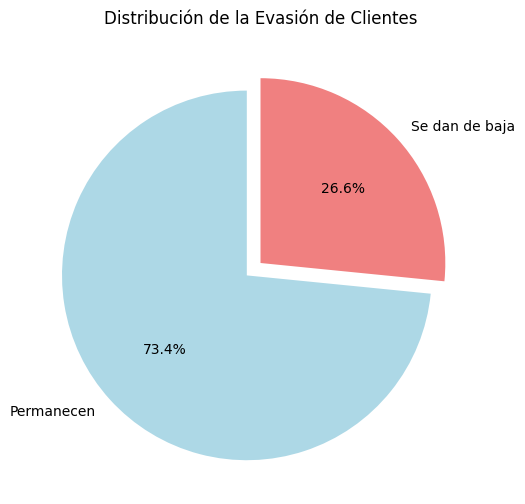

In [217]:
# 0=No 1=Si
plt.figure(figsize=(8, 6))
churn_counts.plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, explode=(0.1, 0), labels=['Permanecen', 'Se dan de baja'])
plt.title('Distribución de la Evasión de Clientes')
plt.ylabel('')  # Eliminar etiqueta de y-axis
plt.show()

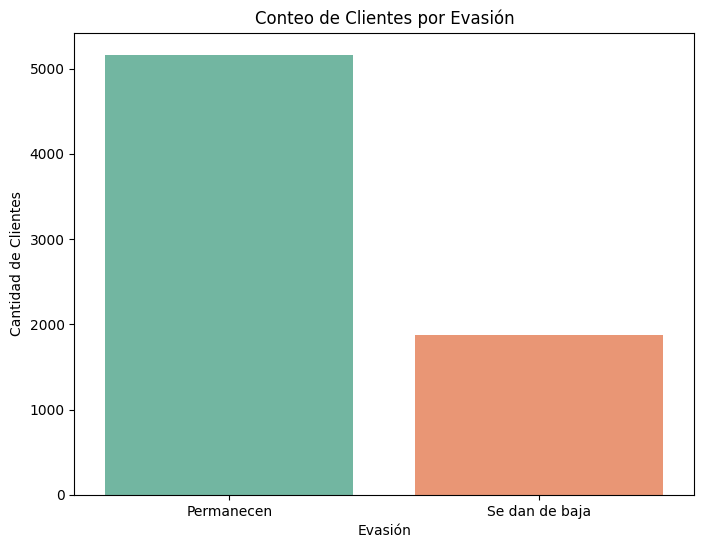

In [195]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Evasion', data=df, palette='Set2')
plt.title('Conteo de Clientes por Evasión')
plt.xlabel('Evasión')
plt.ylabel('Cantidad de Clientes')
plt.xticks([0, 1], ['Permanecen', 'Se dan de baja'], rotation=0)
plt.show()

## Gráficos de evasión segun categorías

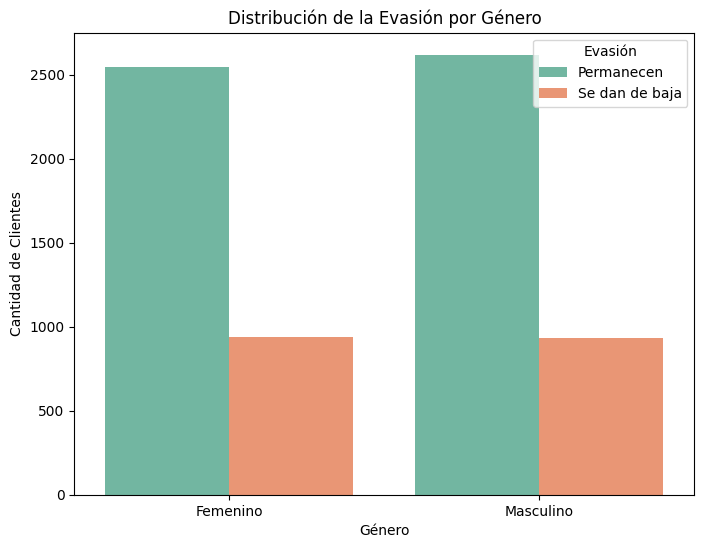

In [218]:
# Gráfico de barras para la distribución de 'Evasión' según 'gender'
plt.figure(figsize=(8, 6))
sns.countplot(x='Genero', hue='Evasion', data=df, palette='Set2')
plt.title('Distribución de la Evasión por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Clientes')
plt.xticks([0, 1], ['Femenino', 'Masculino'], rotation=0)
plt.legend(title='Evasión', labels=['Permanecen', 'Se dan de baja'])
plt.show()

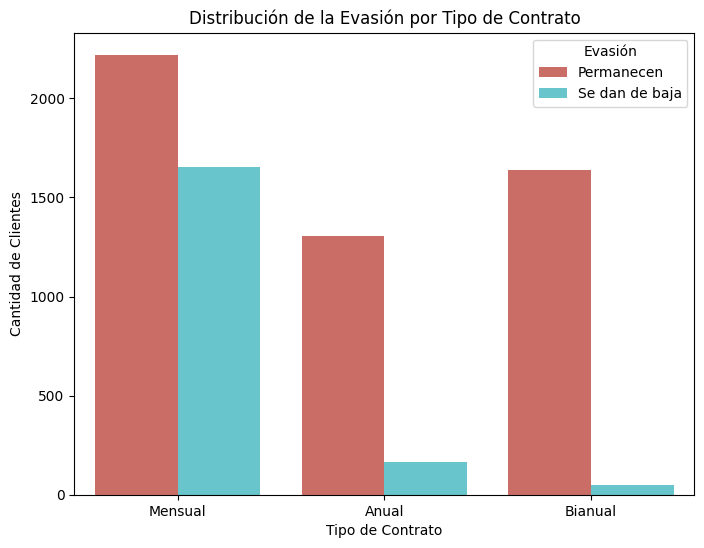

In [219]:
# Gráfico de barras para la distribución de 'Evasión' según 'Tipo de contrato'
plt.figure(figsize=(8, 6))
sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df, palette='hls')
plt.title('Distribución de la Evasión por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.xticks(ticks=[0, 1, 2], labels=['Mensual', 'Anual', 'Bianual'])
plt.legend(title='Evasión', labels=['Permanecen', 'Se dan de baja'])
plt.show()

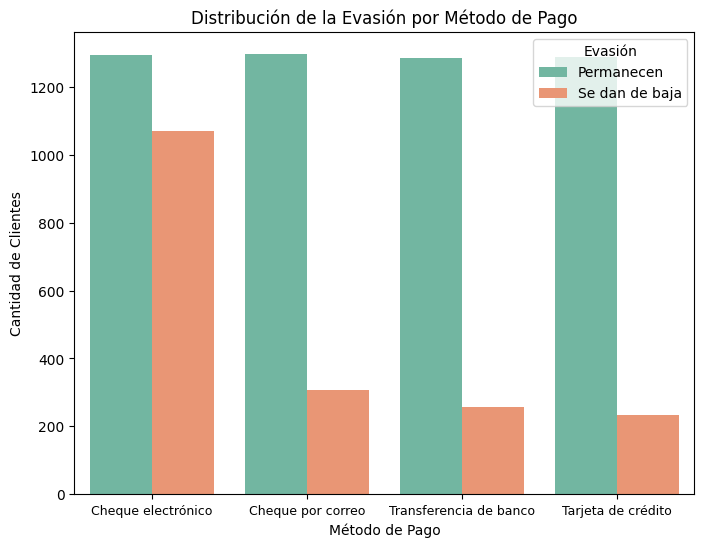

In [202]:
# Gráfico de barras para la distribución de 'Evasión' según 'PaymentMethod'
plt.figure(figsize=(8, 6))
sns.countplot(x='Metodo_Pago', hue='Evasion', data=df, palette='Set2')
plt.title('Distribución de la Evasión por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Clientes')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Cheque electrónico', 'Cheque por correo', 'Transferencia de banco', 'Tarjeta de crédito'], fontsize=9)
plt.legend(title='Evasión', labels=['Permanecen', 'Se dan de baja'])
plt.show()

## Gráfico de evasión por variables númericas

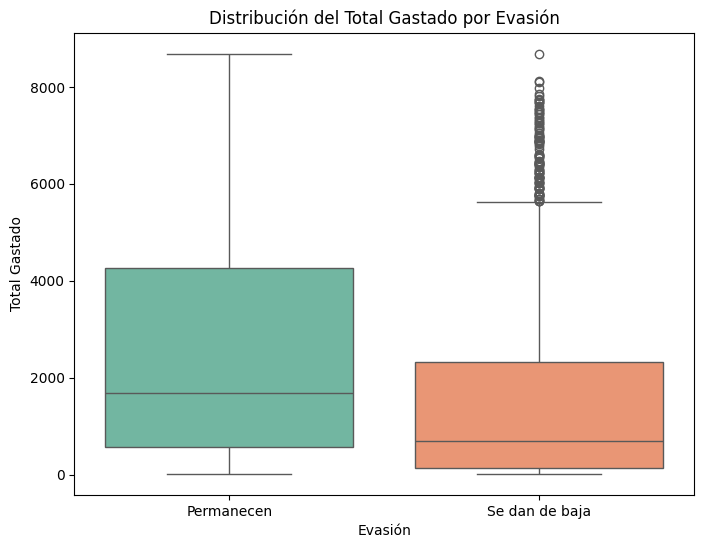

In [203]:
# Gráfico de caja para la distribución del total gastado según 'Churn'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='Facturacion_Total', data=df, palette='Set2')
plt.title('Distribución del Total Gastado por Evasión')
plt.xlabel('Evasión')
plt.ylabel('Total Gastado')
plt.xticks([0, 1], ['Permanecen', 'Se dan de baja'])
plt.show()


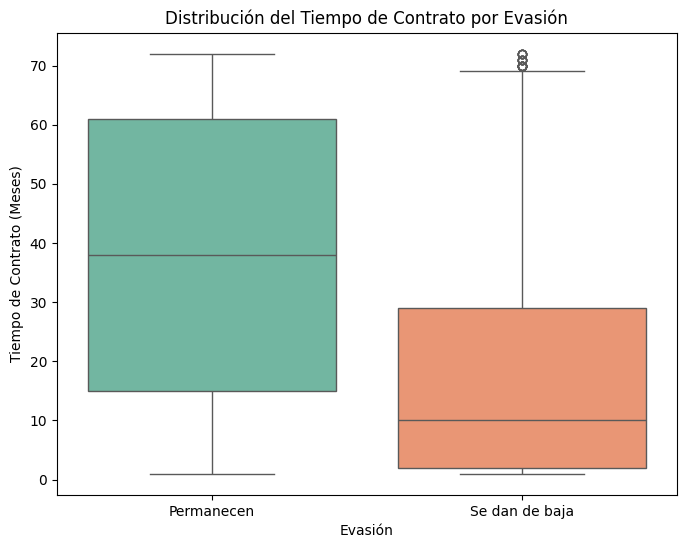

In [204]:
# Gráfico de caja para la distribución del tiempo de contrato según 'Churn'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='Tiempo_con_la_empresa', data=df, palette='Set2')
plt.title('Distribución del Tiempo de Contrato por Evasión')
plt.xlabel('Evasión')
plt.ylabel('Tiempo de Contrato (Meses)')
plt.xticks([0, 1], ['Permanecen', 'Se dan de baja'])
plt.show()


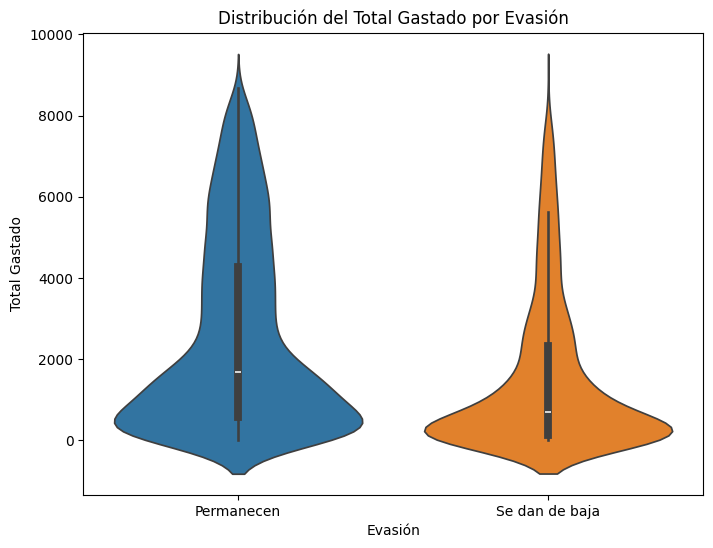

In [223]:
# Gráfico de violín para la distribución del total gastado según 'Churn'
plt.figure(figsize=(8, 6))
sns.violinplot(x='Evasion', y='Facturacion_Total', data=df, palette='tab10')
plt.title('Distribución del Total Gastado por Evasión')
plt.xlabel('Evasión')
plt.ylabel('Total Gastado')
plt.xticks([0, 1], ['Permanecen', 'Se dan de baja'])
plt.show()

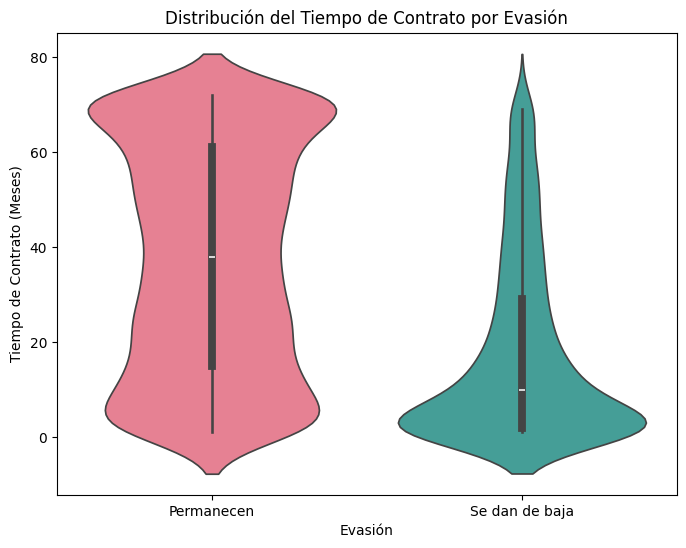

In [228]:
# Gráfico de violín para la distribución del tiempo de contrato según 'Churn'
plt.figure(figsize=(8, 6))
sns.violinplot(x='Evasion', y='Tiempo_con_la_empresa', data=df, palette='husl')
plt.title('Distribución del Tiempo de Contrato por Evasión')
plt.xlabel('Evasión')
plt.ylabel('Tiempo de Contrato (Meses)')
plt.xticks([0, 1], ['Permanecen', 'Se dan de baja'])
plt.show()

#📄Informe final Telecom

# Informe de Análisis de Evasión de Clientes (Churn)

## Introducción

El objetivo principal de este análisis es estudiar la evasión de clientes (churn) en un servicio de telecomunicaciones. La evasión de clientes es un problema crítico para las empresas, ya que implica la pérdida de ingresos y la necesidad de invertir en la captación de nuevos clientes. Este análisis tiene como objetivo identificar patrones y características que ayuden a entender qué factores están asociados con la decisión de los clientes de cancelar el servicio. A partir de este análisis, se podrán desarrollar estrategias para reducir la tasa de evasión y mejorar la retención de clientes.

Durante este análisis, se explorarán tanto las variables numéricas como las categóricas para comprender cómo influencian el comportamiento de los clientes respecto a la cancelación del servicio.

## Limpieza y Tratamiento de Datos

Antes de realizar el análisis exploratorio, los datos fueron sometidos a un proceso de limpieza y tratamiento para asegurar que la información fuera adecuada y consistente para su análisis. A continuación se detallan los pasos realizados:

1. **Importación de los datos:**
   Los datos fueron cargados desde un archivo CSV, el cual contiene información sobre las características de los clientes, su estado de evasión (churn), y detalles sobre los servicios contratados.

2. **Eliminación de valores nulos:**
   Se identificaron y eliminaron los registros con valores nulos para evitar que afectaran los análisis posteriores.

3. **Transformación de variables categóricas:**
   Las variables categóricas, como `Churn`, `gender`, `Contract`, entre otras, fueron transformadas a valores numéricos (0 y 1) utilizando mapeo para poder analizarlas de manera más eficiente.

4. **Creación de nuevas variables:**
   Se generaron nuevas variables, como la columna `Cuentas_Diarias`, que calcula el costo diario de cada cliente en función de su facturación mensual.

5. **Renombramiento de columnas:**
   Las columnas fueron renombradas para asegurar claridad en su interpretación.

6. **Eliminación de registros duplicados y no relevantes:**
   Se eliminaron registros duplicados y aquellas columnas que no aportaban valor para el análisis.

Este proceso permitió obtener un conjunto de datos limpio y estructurado, adecuado para los análisis posteriores.

## Análisis Exploratorio de Datos

Una vez los datos fueron preparados, se realizó un análisis exploratorio para identificar patrones y relaciones entre las variables. A continuación, se presentan algunos de los análisis más relevantes:

### Distribución de la Evasión (Churn)

El análisis inicial consistió en explorar cómo se distribuye la variable `Churn`, es decir, la tasa de evasión de clientes. Se identificó que aproximadamente el **26%** de los clientes cancelaron su servicio, lo que indica un desafío para la retención.

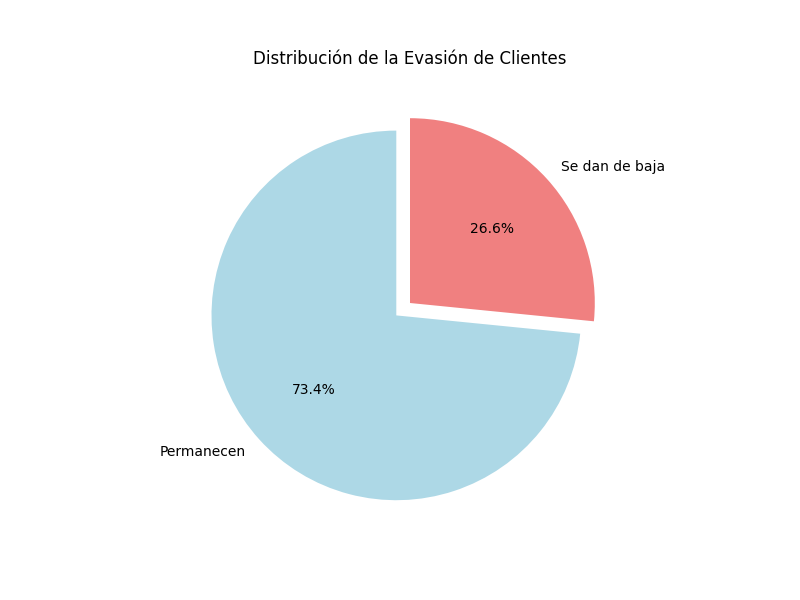

### Distribución de la Evasión por Género

Se observó que no existen diferencias significativas en las tasas de evasión entre hombres y mujeres. Sin embargo, es importante destacar que algunos segmentos podrían necesitar una atención más detallada:

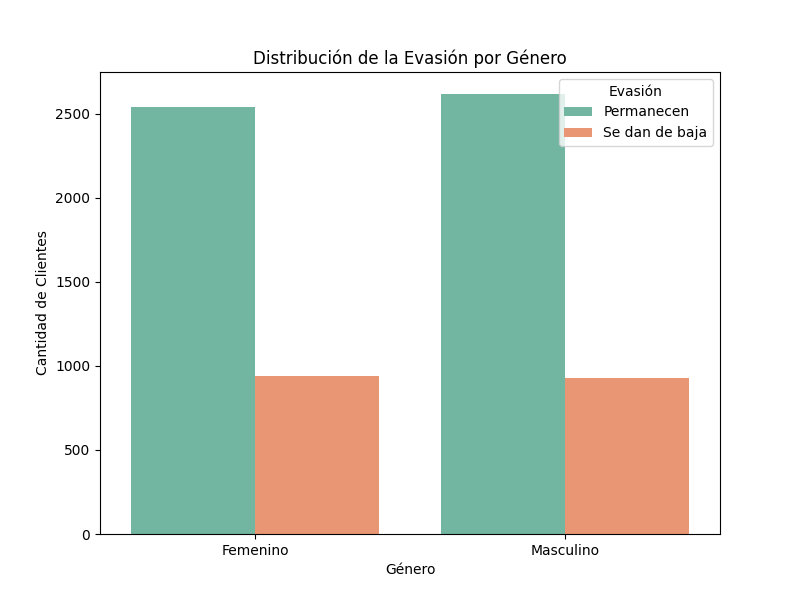

## Distribución de la Evasión por Tipo de Contrato

Se encontró que los clientes con contratos mensuales (**Mensual**) tienen una mayor tasa de evasión. En cambio, los clientes con contratos de un año o dos años son más propensos a quedarse.

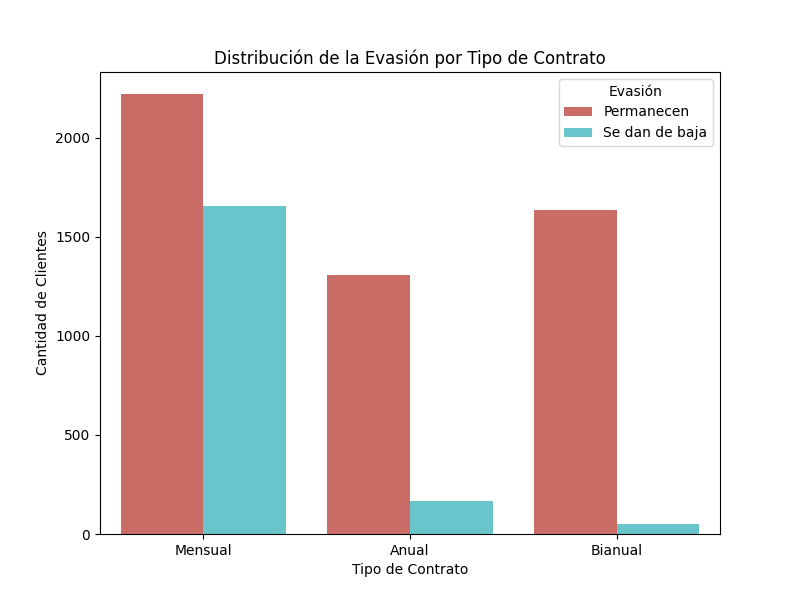

## Distribución del Total Gastado y Tiempo de Contrato

Se observó que los clientes que se dan de baja suelen tener **menos tiempo en el servicio** y **menos gasto acumulado** en comparación con los clientes que permanecen. Esta relación puede indicar que los nuevos clientes y aquellos con un bajo compromiso financiero son más propensos a cancelar el servicio.

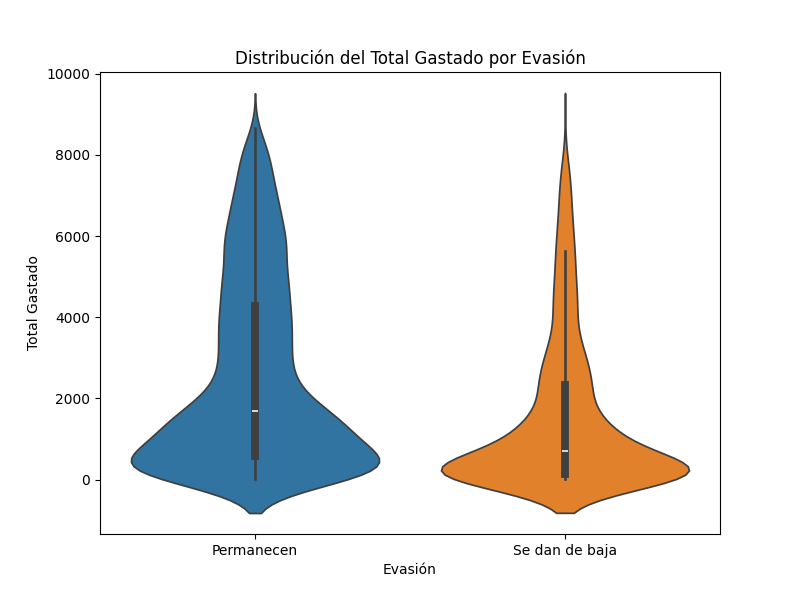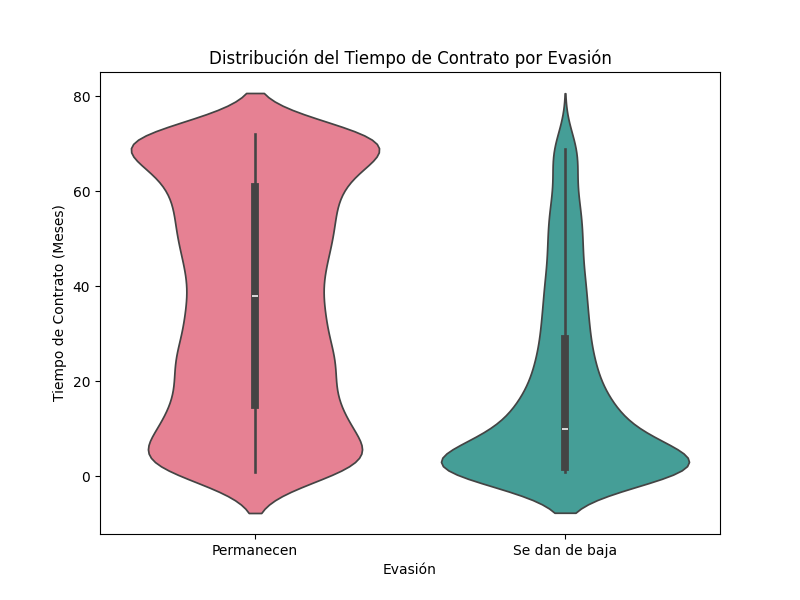

## Conclusiones e Insights

A partir del análisis realizado, se pueden extraer los siguientes **insights clave**:

1. **Clientes con contratos a largo plazo tienen menos probabilidades de cancelar el servicio**. Esto sugiere que ofrecer incentivos para compromisos a largo plazo puede ser una estrategia efectiva para reducir la evasión.

2. **Los clientes que gastan más en promedio tienden a permanecer**. Esto puede indicar que los clientes que invierten más en servicios adicionales están más satisfechos o más comprometidos con la empresa.

3. **El tiempo de contrato es un buen predictor de la evasión**. Los clientes con menos tiempo en el servicio son más propensos a cancelarlo, lo que sugiere que los nuevos clientes podrían necesitar una mejor estrategia de retención.

4. **El tipo de contrato influye significativamente en la evasión**. Los clientes con contratos de "mes a mes" tienen una tasa de cancelación más alta. Es posible que una revisión de las condiciones de estos contratos pueda ayudar a reducir la evasión.

5. **El gasto mensual y total** también es relevante, pues los clientes con mayor facturación tienen una mayor tendencia a quedarse. Considerar ofrecer descuentos o beneficios para clientes con menor facturación podría ser una opción para mejorar la retención.


## Recomendaciones

Con base en los resultados obtenidos, las siguientes recomendaciones estratégicas podrían ayudar a reducir la evasión de clientes:

1. **Fomentar contratos a largo plazo**: Ofrecer descuentos o promociones a clientes que se comprometan a contratos de 1 o 2 años podría aumentar la retención y reducir la evasión.

2. **Segmentación y atención personalizada**: Identificar a los clientes de bajo gasto y ofrecerles **incentivos personalizados** para que aumenten su facturación o permanezcan en el servicio.

3. **Mejorar la experiencia del cliente**: Los clientes nuevos podrían beneficiarse de un programa de **onboarding** o de fidelización que les haga sentir más comprometidos con la marca.

4. **Revisión de contratos de mes a mes**: Los clientes con este tipo de contrato tienen una tasa de evasión mayor. Analizar si ofrecerles planes más flexibles o con beneficios adicionales puede ayudarlos a quedarse.

5. **Análisis de precios y promociones**: Ofrecer promociones o ajustes en los precios para clientes con altos valores de evasión podría mitigar la tasa de cancelaciones.

Este análisis proporciona una base sólida sobre la cual implementar estrategias de retención más efectivas y personalizadas para cada segmento de clientes.
